# Creating Plots for Data Viz 

In [147]:
#packages
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [148]:
#loading data
df = pd.read_parquet('/Users/pdeguz01/Documents/git/IDS705_TeamPandas/00-Data/Data Viz Data/MergedDataset.parquet')

In [149]:
#df details
col_list = df.columns.tolist()

In [150]:
print(col_list)

['INSPECTION_DATE', 'STORE_NAME', 'STREET_ADDRESS', 'CITY', 'ZIP5', 'SERVICE_DESCRIPTION', 'SCORE', 'GRADE', 'STREET_ADDRESS_LINE2', 'INSPDATE_YEAR', 'Latitude', 'Longitude', 'Accuracy Score', 'Accuracy Type', 'Number', 'Street', 'Unit Type', 'Unit Number', 'City', 'State', 'County', 'Zip', 'Country', 'Source', 'geometry', 'buffer', 'STATEFP', 'COUNTYFP', 'TRACTCE', 'PRIMARY_CENSUSTRACT', 'GEOIDFQ', 'NAME', 'NAMELSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'AVG_INCOME_NEARBY_TRACTS', 'AVG_HH_SIZE_NEARBY_TRACTS', 'AVG_RENT_NEARBY_TRACTS', 'AVG_POP_NEARBY_TRACTS', 'ST_ABBR', 'LOCATION', 'AREA_SQMI', 'E_TOTPOP', 'E_HU', 'E_HH', 'E_POV150', 'E_UNEMP', 'E_HBURD', 'E_NOHSDP', 'E_UNINSUR', 'E_AGE65', 'E_AGE17', 'E_DISABL', 'E_SNGPNT', 'E_LIMENG', 'E_MINRTY', 'E_MUNIT', 'E_MOBILE', 'E_CROWD', 'E_NOVEH', 'E_GROUPQ', 'EP_POV150', 'EP_UNEMP', 'EP_HBURD', 'EP_NOHSDP', 'EP_UNINSUR', 'EP_AGE65', 'EP_AGE17', 'EP_DISABL', 'EP_SNGPNT', 'EP_LIMENG', 'EP_MINRTY', 'EP_MUNIT', 'EP

In [151]:
#cleaning vars
df = df[df["State"] == "CA"]

df["SCORE"] = pd.to_numeric(df["SCORE"], errors="coerce")
df["RPL_THEMES"] = pd.to_numeric(df["RPL_THEMES"], errors="coerce")
df["RPL_THEMES"] = df["RPL_THEMES"].replace(-999, pd.NA)


# Plot 1

A density bar plot for the count of how many not passing restaurants there are in social vulnerable areas
So like a histogram (but data is filtered to restaurants that don’t pass, and the y axis is the number of restaurants and x axis is the Social Vulnerability Index scores)


In [152]:
#filter df
plotting_cols = ["INSPECTION_DATE", "STORE_NAME", "SCORE", "RPL_THEMES"]
df_filtered = df[plotting_cols]


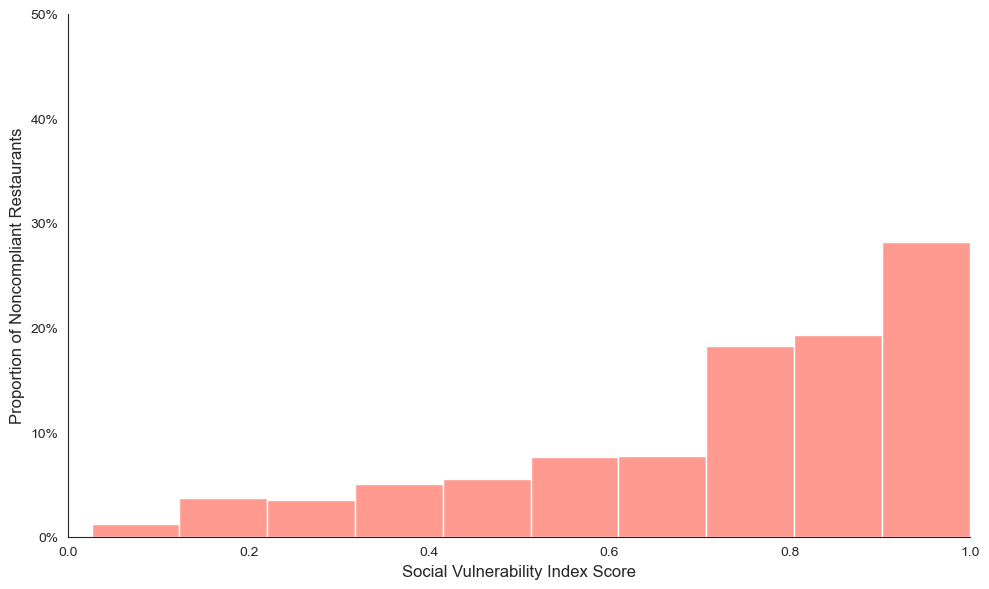

In [153]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick


# Convert RPL_THEMES to numeric and filter to failing
df_fail = df[df["SCORE"] < 90].dropna(subset=["RPL_THEMES"])
df_fail = df_fail[plotting_cols]

plt.figure(figsize=(10,6))
sns.set_style("white")

sns.histplot(
    data=df_fail,
    x="RPL_THEMES",
    bins=10,
    color="#FF6F61",
    alpha=0.7,
    stat="probability"          
)

# Set y-axis from 0% to 50%
plt.ylim(0, 0.5)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))
plt.gca().yaxis.set_major_locator(plt.MultipleLocator(0.1))  # ticks every 10%

plt.xlabel("Social Vulnerability Index Score", fontsize=12)
plt.ylabel("Proportion of Noncompliant Restaurants", fontsize=12)
sns.despine()
plt.xlim(0,1)
plt.ylim(0,0.5)
plt.tight_layout()
plt.show()


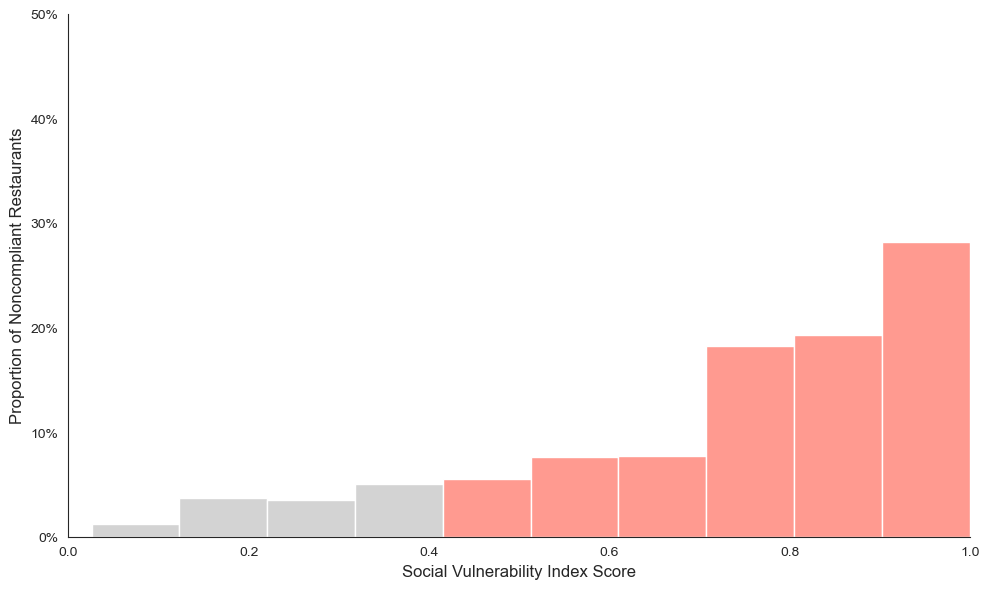

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
import numpy as np

# Filter failing restaurants
df_fail = df[df["SCORE"] < 90].dropna(subset=["RPL_THEMES"])
df_fail = df_fail[plotting_cols]

plt.figure(figsize=(10,6))
sns.set_style("white")

# Plot histogram (probabilities for the full dataset)
hist = sns.histplot(
    data=df_fail,
    x="RPL_THEMES",
    bins=10,
    color="#FF6F61",  # default color
    alpha=0.7,
    stat="probability"
)

# Highlight bars with RPL_THEMES < 0.5 in grey
# Each bar is a Rectangle in hist.patches
for patch in hist.patches:
    # patch.get_x() is the left edge of the bin
    # patch.get_width() is the bin width
    bin_left = patch.get_x()
    bin_right = bin_left + patch.get_width()
    # If the bin is entirely below 0.5, recolor grey
    if bin_right <= 0.5:
        patch.set_facecolor("lightgray")

plt.xlabel("Social Vulnerability Index Score", fontsize=12)
plt.ylabel("Proportion of Noncompliant Restaurants", fontsize=12)

# Y-axis formatting
plt.ylim(0, 0.5)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))
plt.gca().yaxis.set_major_locator(plt.MultipleLocator(0.1))

sns.despine()
plt.xlim(0,1)
plt.tight_layout()
plt.show()


#Nearly 60% of restuarants in LA county are in the top half of highly socially vulnerable Census tracts.

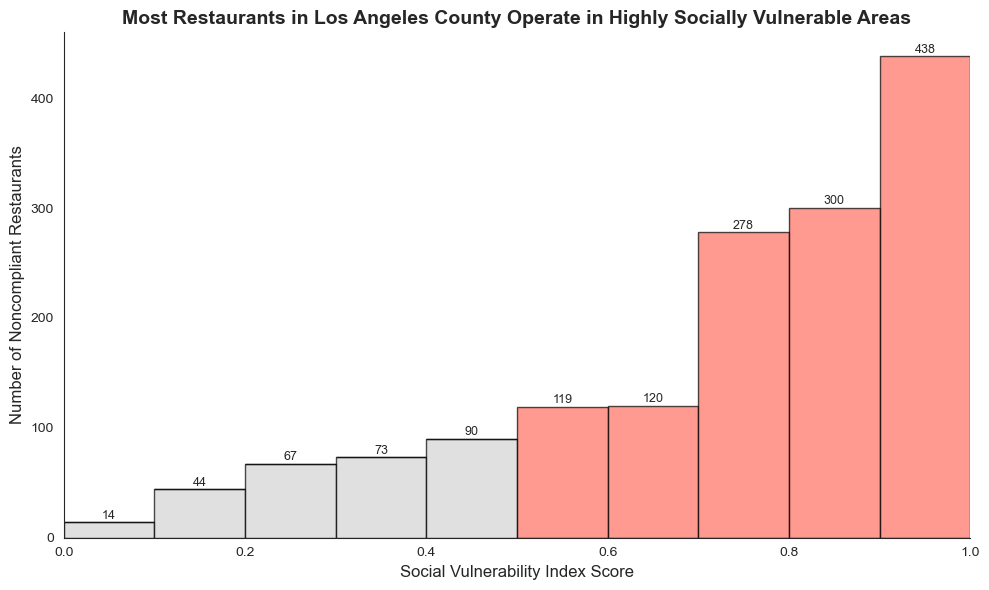

In [155]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.set_style("white")

# Subsets
df_low = df_fail[df_fail["RPL_THEMES"] < 0.5]
df_high = df_fail[df_fail["RPL_THEMES"] >= 0.5]

bins = 10
bin_edges = np.linspace(0, 1, bins + 1)

# Compute histogram counts
low_counts, _ = np.histogram(df_low["RPL_THEMES"], bins=bin_edges)
high_counts, _ = np.histogram(df_high["RPL_THEMES"], bins=bin_edges)

# Bar widths and positions
width = bin_edges[1] - bin_edges[0]
bin_centers = bin_edges[:-1] + width/2

# Plot low group (gray)
plt.bar(bin_centers, low_counts, 
        width=width, color="lightgray", edgecolor="black", alpha=0.7, label="< 0.5")

# Plot high group (stacked on top, matching seaborn stacking)
plt.bar(bin_centers, high_counts, 
        width=width, bottom=low_counts, color="#FF6F61", edgecolor="black", alpha=0.7, label="≥ 0.5")

# Add text labels for total counts
total_counts = low_counts + high_counts
for x, y in zip(bin_centers, total_counts):
    if y > 0:
        plt.text(x, y + 0.5, str(y), ha="center", va="bottom", fontsize=9)

plt.xlabel("Social Vulnerability Index Score", fontsize=12)
plt.ylabel("Number of Noncompliant Restaurants", fontsize=12)
plt.title("Most Restaurants in Los Angeles County Operate in Highly Socially Vulnerable Areas",
          fontsize=14, weight="bold")
sns.despine()
plt.xlim(0, 1)
plt.tight_layout()
plt.show()


In [156]:
#1543 total restuarants in failing CA dataset
1255

1255

# Plot 2

Maybe a plot with like 5-10 top Census tracts with the most poorly performing restaurants (group by Census tracts, rank by # of restaurants that did not pass inspection)
Incorporate # of violations


In [157]:
#prep data
df_fail = df[df["SCORE"] < 90].dropna(subset=["RPL_THEMES"])
plotting_cols_tracts = ["INSPECTION_DATE", "STORE_NAME", "SCORE", "RPL_THEMES", "PRIMARY_CENSUSTRACT", "CITY"]
df_fail = df_fail[plotting_cols_tracts]


In [158]:
# Count failing restaurants per tract
tract_counts = (
    df_fail
    .groupby("PRIMARY_CENSUSTRACT")
    .size()
    .reset_index(name="fail_count")
    .sort_values("fail_count", ascending=False)
    .head(10)  # top 10
)

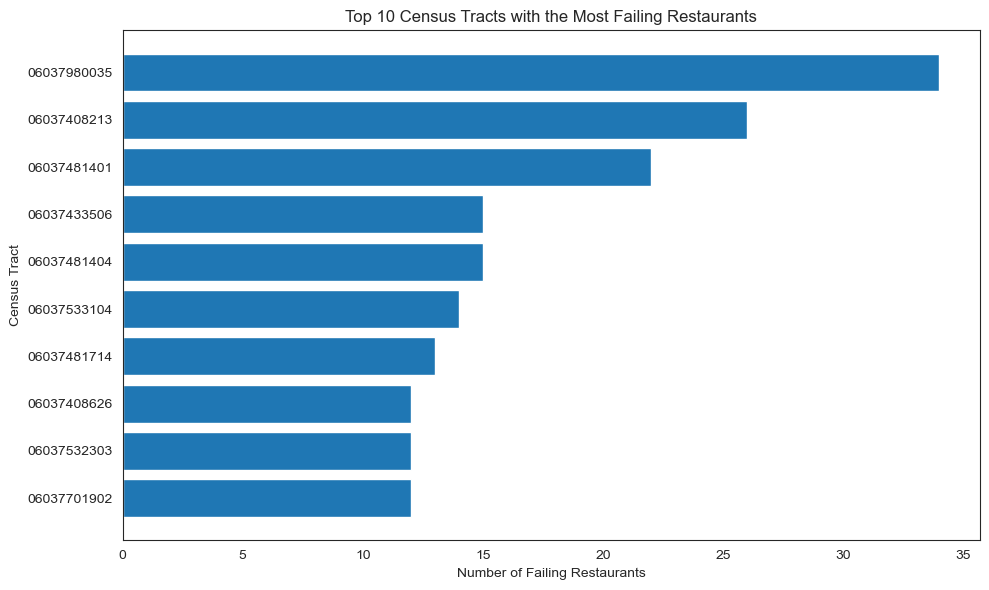

In [159]:
plt.figure(figsize=(10,6))

plt.barh(
    tract_counts["PRIMARY_CENSUSTRACT"].astype(str),
    tract_counts["fail_count"]
)

plt.xlabel("Number of Failing Restaurants")
plt.ylabel("Census Tract")
plt.title("Top 10 Census Tracts with the Most Failing Restaurants")

plt.gca().invert_yaxis()  # largest at top
plt.tight_layout()
plt.show()

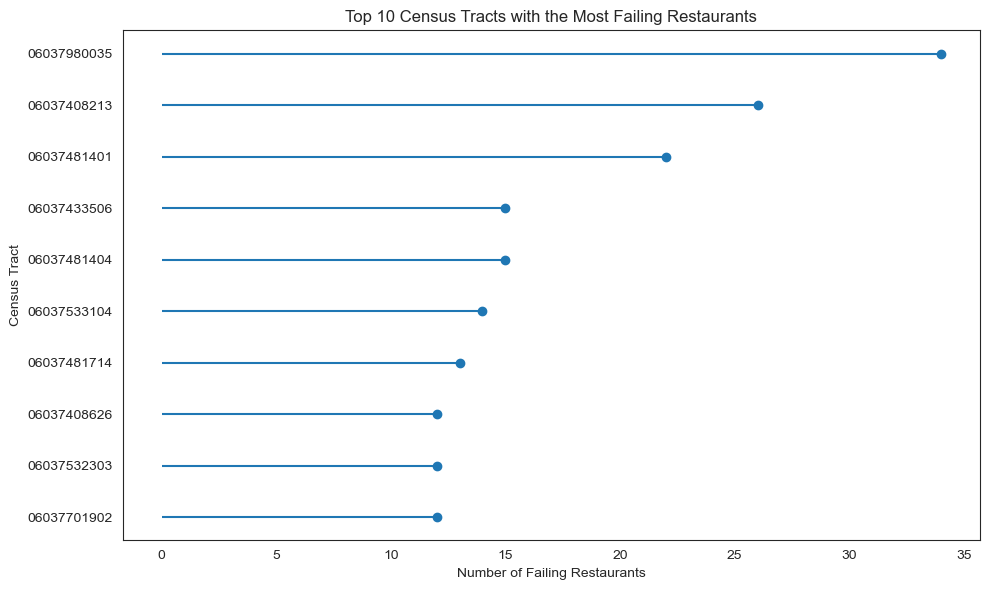

In [160]:
plt.figure(figsize=(10,6))

plt.hlines(
    y=tract_counts["PRIMARY_CENSUSTRACT"].astype(str),
    xmin=0,
    xmax=tract_counts["fail_count"]
)
plt.plot(
    tract_counts["fail_count"],
    tract_counts["PRIMARY_CENSUSTRACT"].astype(str),
    "o"
)

plt.xlabel("Number of Failing Restaurants")
plt.ylabel("Census Tract")
plt.title("Top 10 Census Tracts with the Most Failing Restaurants")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [161]:
# 1. Total inspections per tract
total_by_tract = (
    df.groupby("CITY")
      .size()
      .reset_index(name="total_inspections")
)

# 2. Failing inspections per tract
fails_by_tract = (
    df_fail.groupby("CITY")
           .size()
           .reset_index(name="fail_count")
)

# 3. Merge + compute failure rate
tract_rates = (
    total_by_tract
    .merge(fails_by_tract, on="CITY", how="left")
    .fillna({"fail_count": 0})
)

tract_rates["failure_rate"] = tract_rates["fail_count"] / tract_rates["total_inspections"]

# Sort highest failure rates at top
tract_rates = tract_rates.sort_values("failure_rate", ascending=False)

tract_rates.head(10)

,CITY,total_inspections,fail_count,failure_rate
27,CITY OF INDUSTRY,5,3.0,0.600000
143,VALYERMO,2,1.0,0.500000
65,LAKE HUGHES,4,1.0,0.250000
38,EAST LOS ANGELES,8,2.0,0.250000
112,ROWLAND HEIGHTS,161,37.0,0.229814
55,INDUSTRY,168,36.0,0.214286
156,WRIGHTWOOD,5,1.0,0.200000
0,ACTON,22,4.0,0.181818
115,SAN GABRIEL,323,52.0,0.160991
23,CASTAIC,57,9.0,0.157895


In [162]:
#filter to over 10 inspections

tract_rates_filtered = tract_rates[tract_rates["total_inspections"] >= 10]

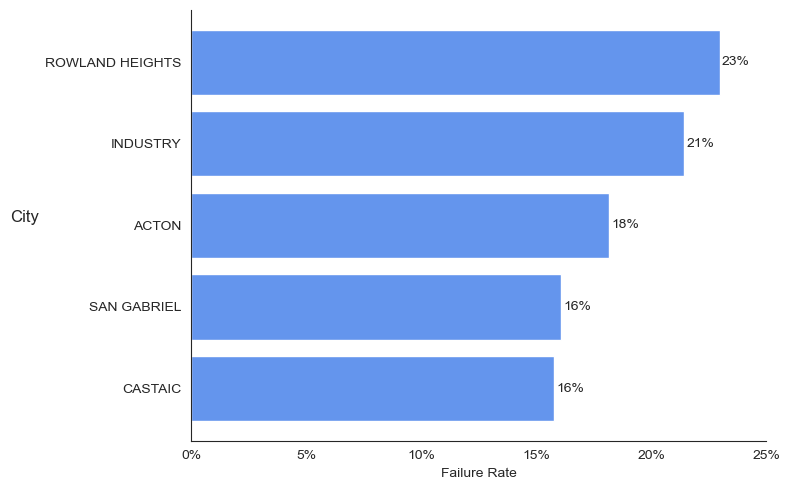

In [163]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Sort and select top 5
top5 = tract_rates_filtered.sort_values("failure_rate", ascending=False).head(5)

plt.figure(figsize=(8,5))

bars = plt.barh(
    top5["CITY"].astype(str),
    top5["failure_rate"],
    color="cornflowerblue"
)

plt.xlabel("Failure Rate")
plt.ylabel("City", rotation=0, labelpad=15, fontsize=12)

#plt.title("Cities in North and East LA County Lead in Restaurant Health Inspection Failure Rates")

plt.gca().invert_yaxis()   # highest rate at top

# --- Add data labels ---
for bar, rate in zip(bars, top5["failure_rate"]):
    plt.text(
        bar.get_width() + 0.001,       # small offset to the right of the bar
        bar.get_y() + bar.get_height()/2,
        f"{rate:.0%}",                 # percentage label
        va="center",
        #fontweight='bold'
    )

plt.xlim(0, 0.25)                       # 0% to 100%

plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))

sns.despine()
plt.tight_layout()
plt.show()


In [164]:
#plotting